# NETFLIX

## Data Exploration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv(r"C:\Users\nikit\Downloads\netflix_titles.csv")

In [3]:
# show first five rows
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [4]:
# shape of dataset 
df.shape

(8807, 12)

In [5]:
# dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [6]:
# check missingg values
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [7]:
# chack and remove duplicate values 
df.duplicated().sum()
df.drop_duplicates(inplace=True)

## Data cleaninng

In [8]:
# Fill missing values
df['director'].fillna('Unknown', inplace=True)
df['cast'].fillna('Unknown', inplace=True)
df['country'].fillna('Unknown', inplace=True)
df['rating'].fillna(df['rating'].mode()[0], inplace=True)
df['date_added'] = df['date_added'].ffill()

In [9]:
# Remove missing values
df.dropna(inplace=True)

In [10]:
df.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

In [11]:
# Convert date_added into Datetime Format
df['date_added'] = df['date_added'].str.strip()
df['date_added'] = pd.to_datetime(df['date_added'])

In [12]:
df['date_added'].dtype

dtype('<M8[ns]')

In [13]:
# Extract Year, month and Day
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month_name()
df['day_added'] = df['date_added'].dt.day

In [14]:
df[['date_added', 'year_added', 'month_added', 'day_added']].head()

,date_added,year_added,month_added,day_added
0,2021-09-25,2021,September,25
1,2021-09-24,2021,September,24
2,2021-09-24,2021,September,24
3,2021-09-24,2021,September,24
4,2021-09-24,2021,September,24


## Descriptive Statistics

In [15]:
# Statistical Summary of Dataset
df.describe(include='all')

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added,day_added
count,8804,8804,8804,8804,8804,8804,8804,8804.000000,8804,8804,8804,8804,8804.000000,8804,8804.00000
unique,8804,2,8804,4528,7692,749,NaN,NaN,14,220,514,8772,NaN,12,NaN
top,s1,Movie,Dick Johnson Is Dead,Unknown,Unknown,United States,NaN,NaN,TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope...",NaN,July,NaN
freq,1,6128,1,2634,825,2815,NaN,NaN,3211,1793,362,4,NaN,827,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,2019-05-16 21:51:55.856429056,2014.180259,NaN,NaN,NaN,NaN,2018.871081,NaN,12.49716
min,NaN,NaN,NaN,NaN,NaN,NaN,2008-01-01 00:00:00,1925.000000,NaN,NaN,NaN,NaN,2008.000000,NaN,1.00000
25%,NaN,NaN,NaN,NaN,NaN,NaN,2018-04-05 00:00:00,2013.000000,NaN,NaN,NaN,NaN,2018.000000,NaN,1.00000
50%,NaN,NaN,NaN,NaN,NaN,NaN,2019-07-01 00:00:00,2017.000000,NaN,NaN,NaN,NaN,2019.000000,NaN,13.00000
75%,NaN,NaN,NaN,NaN,NaN,NaN,2020-08-18 06:00:00,2019.000000,NaN,NaN,NaN,NaN,2020.000000,NaN,20.00000
max,NaN,NaN,NaN,NaN,NaN,NaN,2021-09-25 00:00:00,2021.000000,NaN,NaN,NaN,NaN,2021.000000,NaN,31.00000


In [16]:
# Chack Data type 
df.dtypes

show_id                 object
type                    object
title                   object
director                object
cast                    object
country                 object
date_added      datetime64[ns]
release_year             int64
rating                  object
duration                object
listed_in               object
description             object
year_added               int32
month_added             object
day_added                int32
dtype: object

In [17]:
# shape of data set
df.shape

(8804, 15)

In [18]:
# show column names
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description',
       'year_added', 'month_added', 'day_added'],
      dtype='object')

In [19]:
# Number of Movies and TV Shows
df['type'].value_counts()

type
Movie      6128
TV Show    2676
Name: count, dtype: int64

In [20]:
# Percentage Distribution of Content Type
(df['type'].value_counts(normalize=True) * 100)

type
Movie      69.604725
TV Show    30.395275
Name: proportion, dtype: float64

In [21]:
# Most Common Ratings
df['rating'].value_counts().head(10)

rating
TV-MA    3211
TV-14    2160
TV-PG     863
R         799
PG-13     490
TV-Y7     334
TV-Y      307
PG        287
TV-G      220
NR         80
Name: count, dtype: int64

In [22]:
# Top 10 Countries with Most Content
df['country'].value_counts().head(10)

country
United States     2815
India              972
Unknown            831
United Kingdom     419
Japan              245
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Name: count, dtype: int64

In [23]:
# Oldest and Latest Release Year
print("Oldest Release Year :", df['release_year'].min())
print("Latest Release Year :", df['release_year'].max())

Oldest Release Year : 1925
Latest Release Year : 2021


In [24]:
# Most Common Genres
df['listed_in'].value_counts().head(10)

listed_in
Dramas, International Movies                        362
Documentaries                                       359
Stand-Up Comedy                                     334
Comedies, Dramas, International Movies              274
Dramas, Independent Movies, International Movies    252
Kids' TV                                            220
Children & Family Movies                            215
Children & Family Movies, Comedies                  201
Documentaries, International Movies                 186
Dramas, International Movies, Romantic Movies       180
Name: count, dtype: int64


#### Overall Observation:
* The Netflix dataset contains a wide variety of Movies and TV Shows, with Movies being more dominant on the platform. Most content belongs to popular genres like Drama and Comedy and is mainly targeted toward mature audiences.

* The United States contributes the highest amount of content, and Netflix content has increased rapidly after 2015, showing significant growth and expansion of the platform over recent years.


## Data Visualization-----Part-1

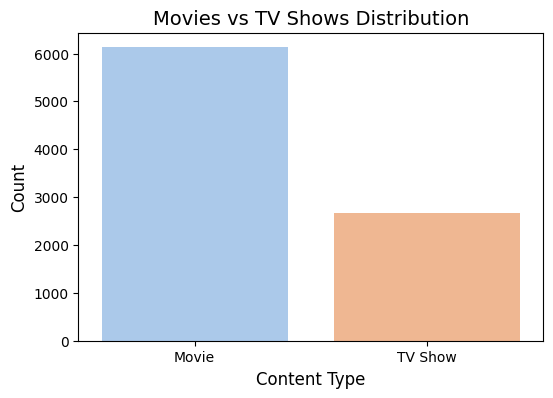

In [25]:
# Movies vs TV Shows Distribution
plt.figure(figsize=(6,4))

sns.countplot(x='type', data=df, hue='type', palette='pastel')

plt.title("Movies vs TV Shows Distribution", fontsize=14)
plt.xlabel("Content Type", fontsize=12)
plt.ylabel("Count", fontsize=12)

plt.show()

Netflix contains more Movies than TV Shows.
Movies dominate the platform content library.

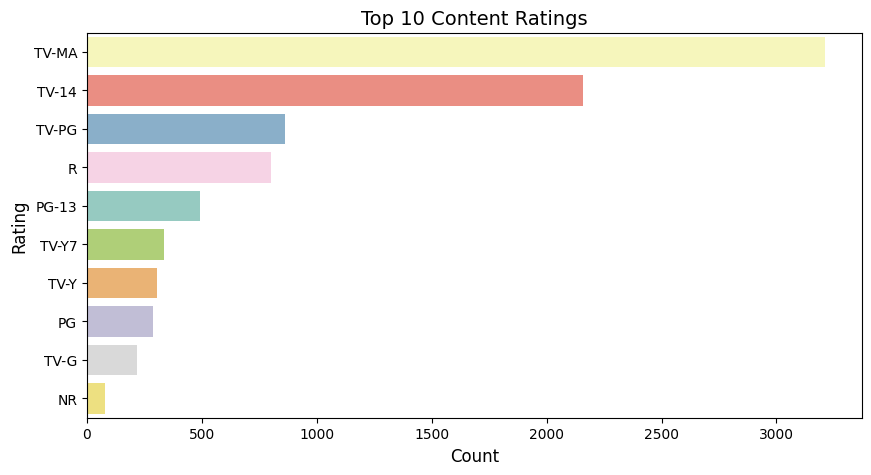

In [26]:
# Top 10 Content Ratings
plt.figure(figsize=(10,5))

sns.countplot(y='rating',
              data=df,
              order=df['rating'].value_counts().index[:10],
              hue='rating',
              palette='Set3',
              legend=False)

plt.title("Top 10 Content Ratings", fontsize=14)
plt.xlabel("Count", fontsize=12)
plt.ylabel("Rating", fontsize=12)

plt.show()

TV-MA and TV-14 are the most common ratings on Netflix.
Most content is targeted toward mature audiences.

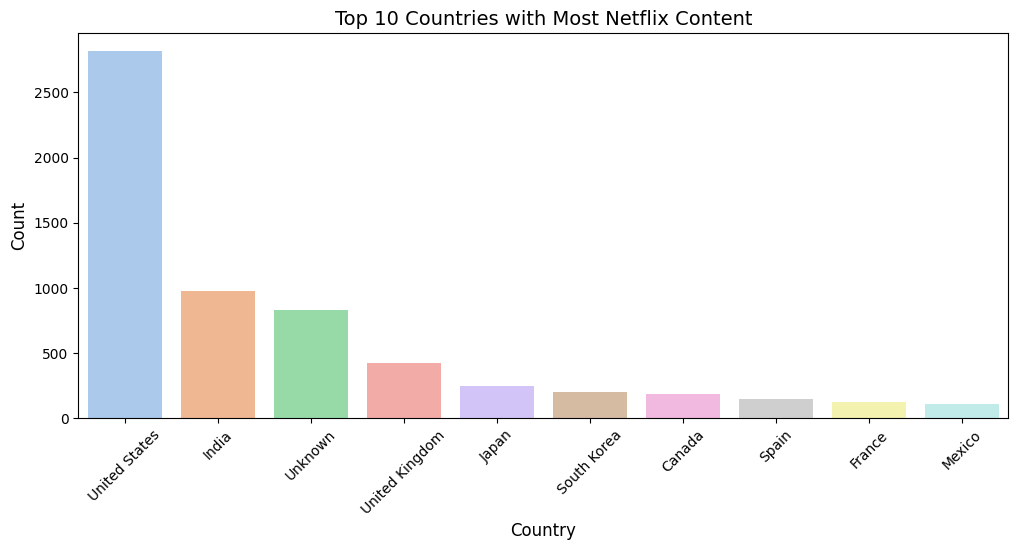

In [27]:
# Top 10 Countries with Most Content
top_country = df['country'].value_counts().head(10)
plt.figure(figsize=(12,5))
sns.barplot(x=top_country.index,
            y=top_country.values,
            hue=top_country.index,
            palette='pastel',
            legend=False)
plt.title("Top 10 Countries with Most Netflix Content", fontsize=14)
plt.xlabel("Country", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.xticks(rotation=45)
plt.show()

The United States contributes the highest amount of content.
India and the United Kingdom are also major contributors.

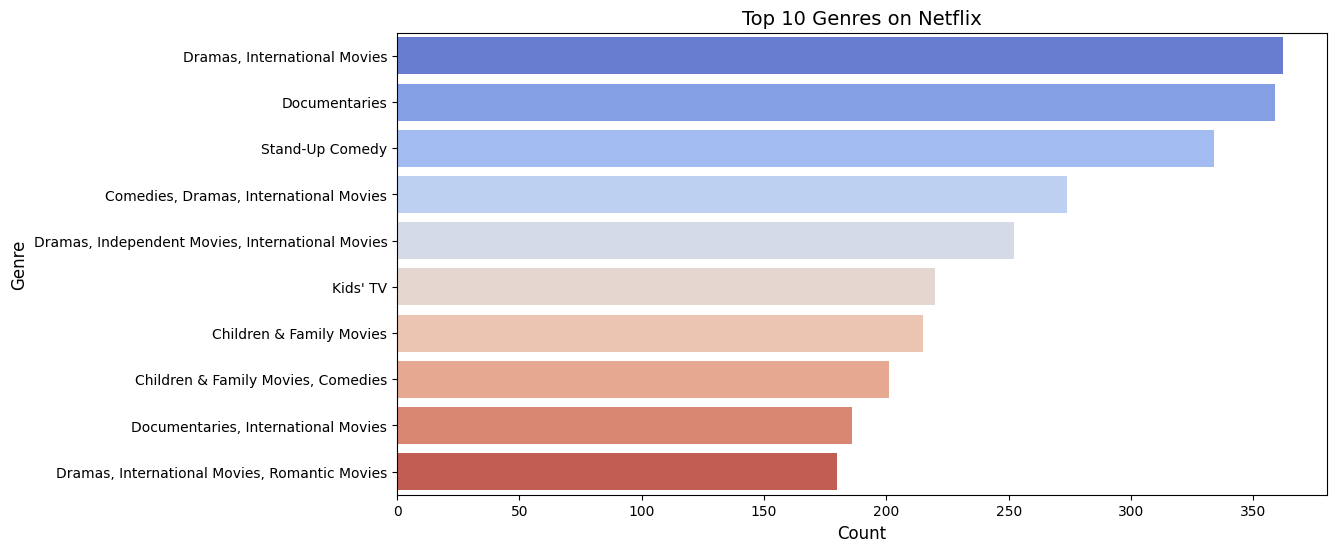

In [28]:
# Top 10 Genres on Netflix
top_genres = df['listed_in'].value_counts().head(10)
plt.figure(figsize=(12,6))
sns.barplot(x=top_genres.values,
            y=top_genres.index,
            hue=top_genres.index,
            palette='coolwarm',
            legend=False)
plt.title("Top 10 Genres on Netflix", fontsize=14)
plt.xlabel("Count", fontsize=12)
plt.ylabel("Genre", fontsize=12)
plt.show()

Drama, International Movies, and Comedy are among the most common genres.
Netflix offers a wide variety of entertainment categories.

## Data Visualization ------ Part 2

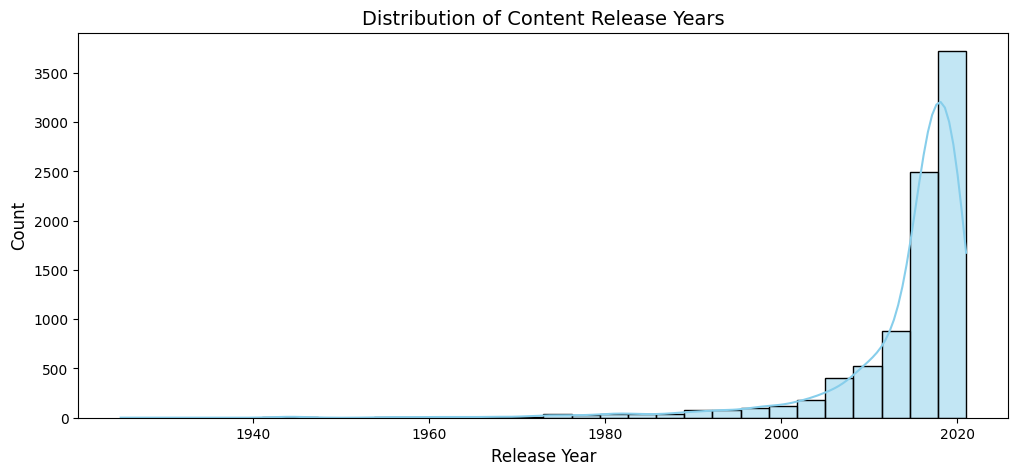

In [29]:
# Content Released Over the Years
plt.figure(figsize=(12,5))
sns.histplot(df['release_year'],
             bins=30,
             kde=True,
             color='skyblue')
plt.title("Distribution of Content Release Years", fontsize=14)
plt.xlabel("Release Year", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.show()

Most Netflix content was released after 2010.
Content production increased rapidly in recent years.

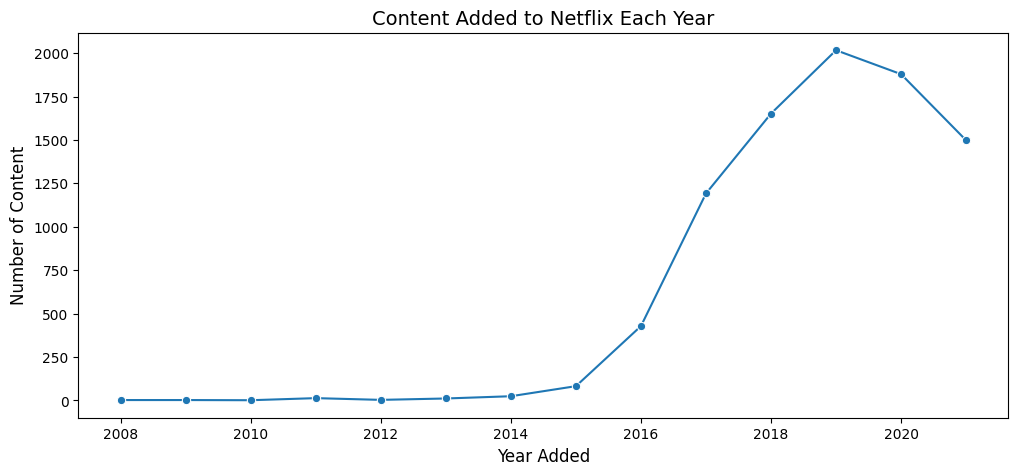

In [30]:
# Number of Content Added Each Year
year_data = df['year_added'].value_counts().sort_index()
plt.figure(figsize=(12,5))
sns.lineplot(x=year_data.index,
             y=year_data.values,
             marker='o')
plt.title("Content Added to Netflix Each Year", fontsize=14)
plt.xlabel("Year Added", fontsize=12)
plt.ylabel("Number of Content", fontsize=12)
plt.show()

Netflix added a large amount of content between 2017 and 2020.
Shows rapid growth of the platform during these years.

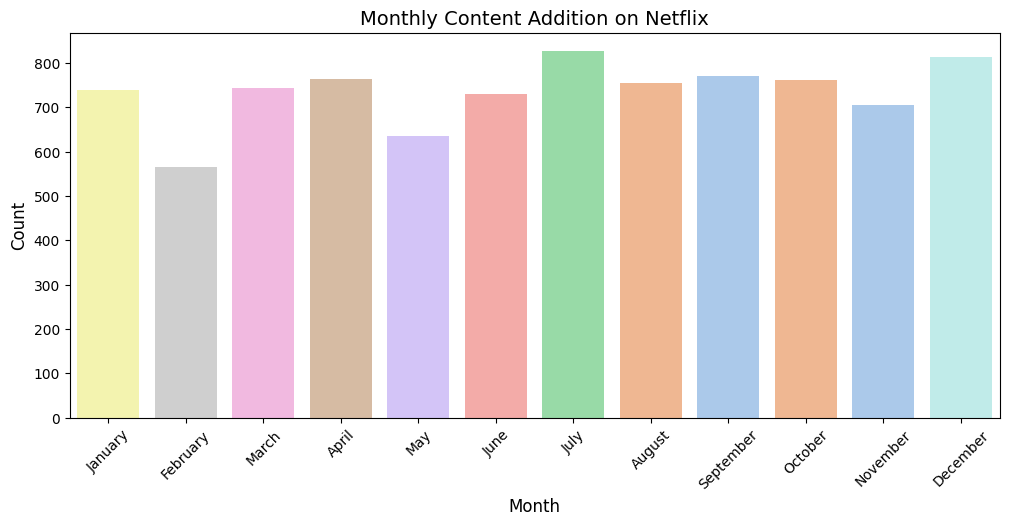

In [31]:
# Monthly Content Addition
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']

plt.figure(figsize=(12,5))

sns.countplot(x='month_added',
              data=df,
              order=month_order,
              hue='month_added',
              palette='pastel',
              legend=False)

plt.title("Monthly Content Addition on Netflix", fontsize=14)
plt.xlabel("Month", fontsize=12)
plt.ylabel("Count", fontsize=12)

plt.xticks(rotation=45)

plt.show()

Some months show higher content additions compared to others.
Netflix content uploads vary throughout the year.

## Data Visualization------Part-3

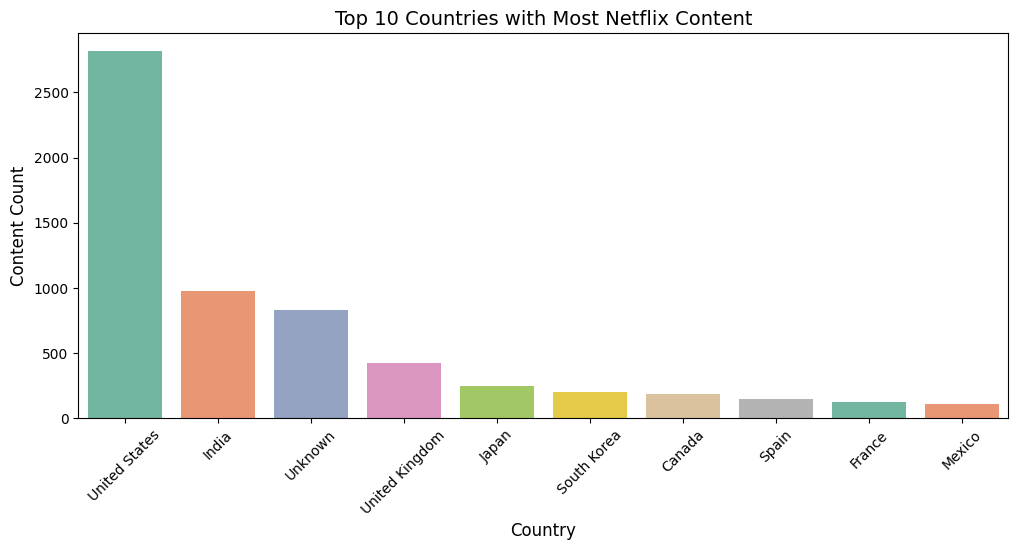

In [32]:
# Top 10 Countries with Most Netflix Content
top_countries = df['country'].value_counts().head(10)

plt.figure(figsize=(12,5))

sns.barplot(x=top_countries.index,
            y=top_countries.values,
            hue=top_countries.index,
            palette='Set2',
            legend=False)

plt.title("Top 10 Countries with Most Netflix Content", fontsize=14)
plt.xlabel("Country", fontsize=12)
plt.ylabel("Content Count", fontsize=12)

plt.xticks(rotation=45)

plt.show()

The United States has the highest Netflix content contribution.
India, the United Kingdom, and Japan are also major contributors.

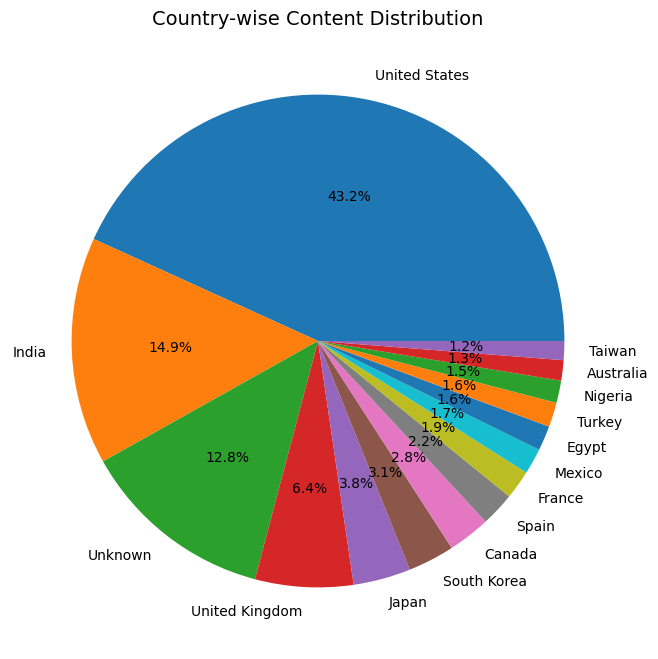

In [33]:
# Country-wise Content Distribution
country_counts = df['country'].value_counts().head(15)

plt.figure(figsize=(10,8))

plt.pie(country_counts.values,
        labels=country_counts.index,
        autopct='%1.1f%%')

plt.title("Country-wise Content Distribution", fontsize=14)

plt.show()

A few countries dominate Netflix content production.
The majority of content comes from limited major regions.

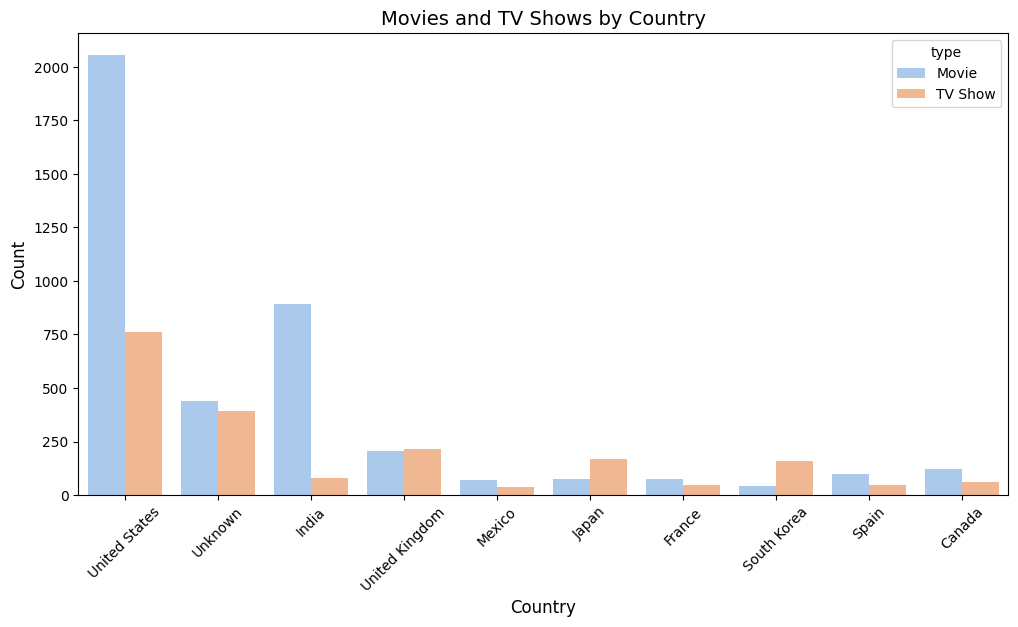

In [34]:
# Movies vs TV Shows by Country
top10 = df['country'].value_counts().head(10).index

filtered_df = df[df['country'].isin(top10)]

plt.figure(figsize=(12,6))

sns.countplot(x='country',
              data=filtered_df,
              hue='type',
              palette='pastel')

plt.title("Movies and TV Shows by Country", fontsize=14)
plt.xlabel("Country", fontsize=12)
plt.ylabel("Count", fontsize=12)

plt.xticks(rotation=45)

plt.show()

Movies dominate in most countries.
Some countries contribute more TV Shows compared to others.

#### Overall Observation of Visualization:

* Netflix content is globally distributed, but a large portion comes from countries like the United States and India.
* Movies are more common than TV Shows across most regions, showing Netflix’s stronger focus on movie-based entertainment.

## Time Series Analysis

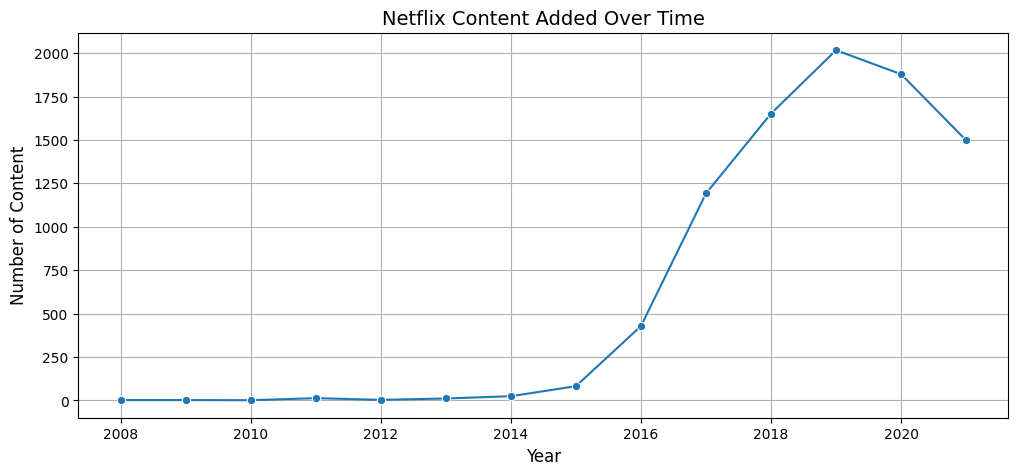

In [35]:
#Content Added Over Time
yearly_content = df['year_added'].value_counts().sort_index()

plt.figure(figsize=(12,5))

sns.lineplot(x=yearly_content.index,
             y=yearly_content.values,
             marker='o')

plt.title("Netflix Content Added Over Time", fontsize=14)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Number of Content", fontsize=12)

plt.grid(True)

plt.show()

Netflix content additions increased rapidly after 2015.
The platform expanded significantly between 2018 and 2020.

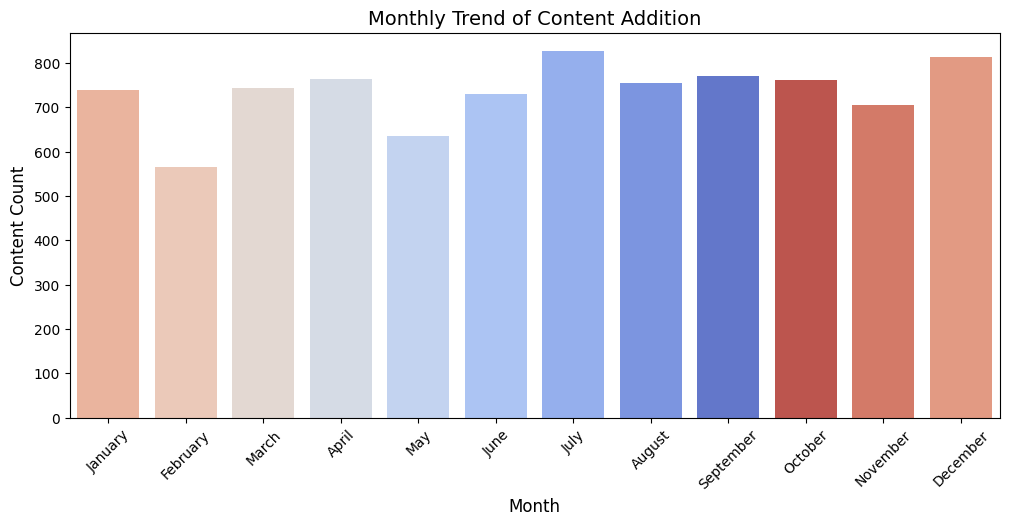

In [36]:
# Monthly Trend of Content Addition
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']

plt.figure(figsize=(12,5))

sns.countplot(x='month_added',
              data=df,
              order=month_order,
              hue='month_added',
              palette='coolwarm',
              legend=False)

plt.title("Monthly Trend of Content Addition", fontsize=14)
plt.xlabel("Month", fontsize=12)
plt.ylabel("Content Count", fontsize=12)

plt.xticks(rotation=45)

plt.show()

Content additions vary across different months.
Some months show higher upload activity than others.

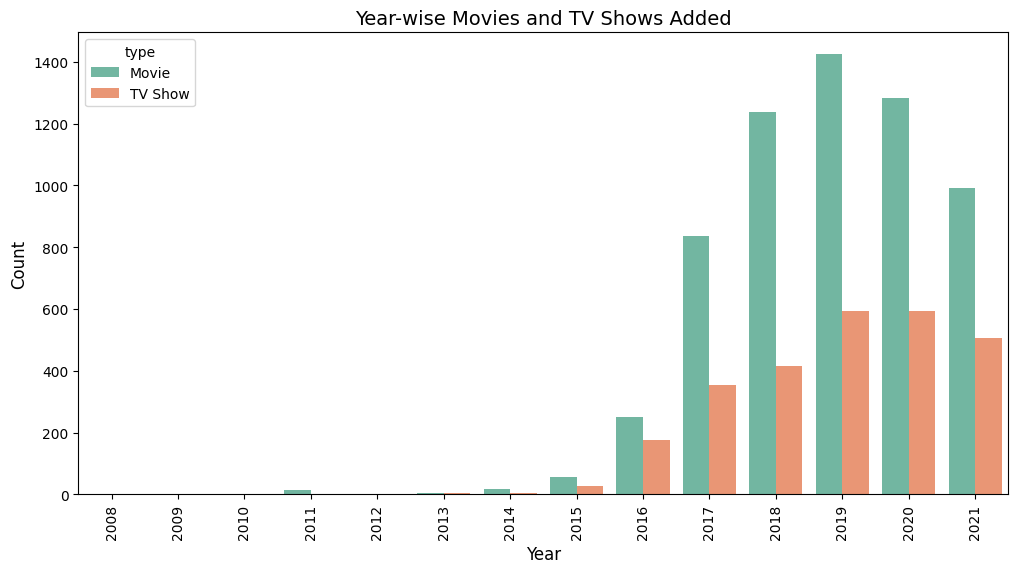

In [37]:
# Year-wise Movies and TV Shows Added
plt.figure(figsize=(12,6))

sns.countplot(x='year_added',
              data=df,
              hue='type',
              palette='Set2')

plt.title("Year-wise Movies and TV Shows Added", fontsize=14)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Count", fontsize=12)

plt.xticks(rotation=90)

plt.show()

Movies were added more frequently than TV Shows over the years.
Both content types increased significantly after 2016.

#### Overall Observation:
- Netflix experienced major growth in content additions after 2015.
- Movies remained dominant throughout the years, while TV Shows also increased gradually over time.

## Content Analysis ------ Part 1

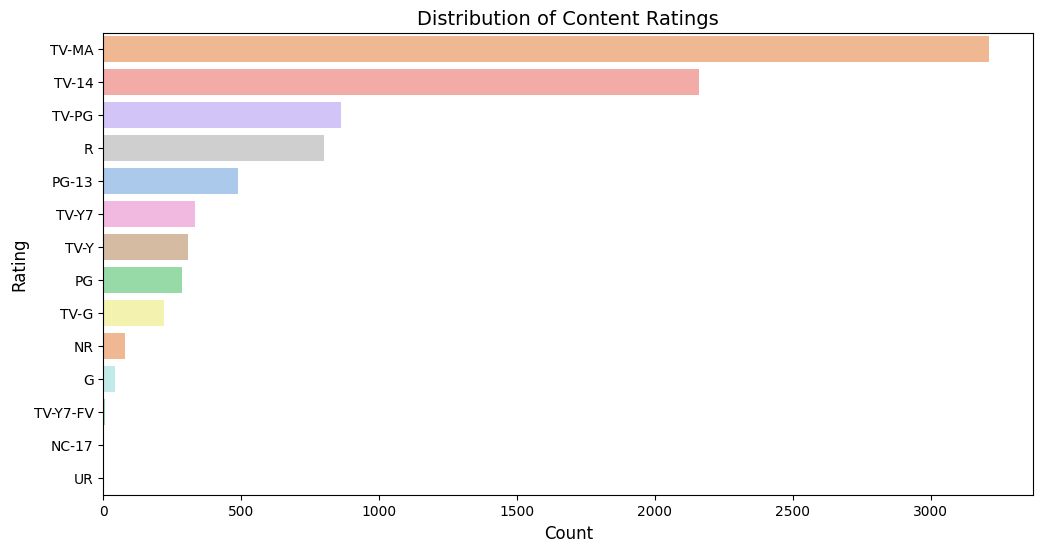

In [38]:
# Distribution of Content Ratings
plt.figure(figsize=(12,6))

sns.countplot(y='rating',
              data=df,
              order=df['rating'].value_counts().index,
              hue='rating',
              palette='pastel',
              legend=False)

plt.title("Distribution of Content Ratings", fontsize=14)
plt.xlabel("Count", fontsize=12)
plt.ylabel("Rating", fontsize=12)

plt.show()

TV-MA and TV-14 are the most common ratings on Netflix.
Most content is targeted toward mature and teenage audiences.

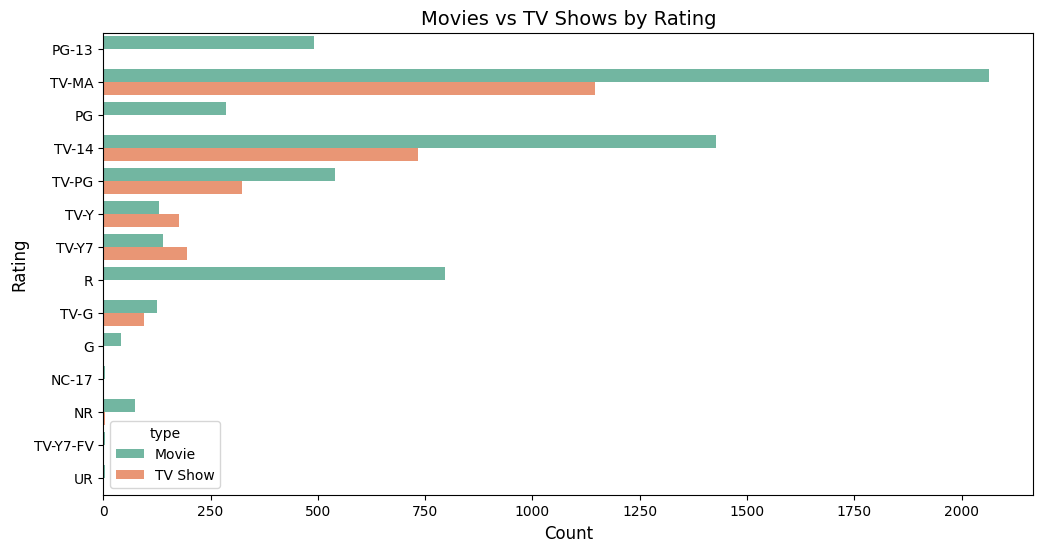

In [39]:
# Movies vs TV Shows Ratings
plt.figure(figsize=(12,6))

sns.countplot(y='rating',
              data=df,
              hue='type',
              palette='Set2')

plt.title("Movies vs TV Shows by Rating", fontsize=14)
plt.xlabel("Count", fontsize=12)
plt.ylabel("Rating", fontsize=12)

plt.show()

Movies dominate most rating categories.
TV Shows are comparatively fewer in number.

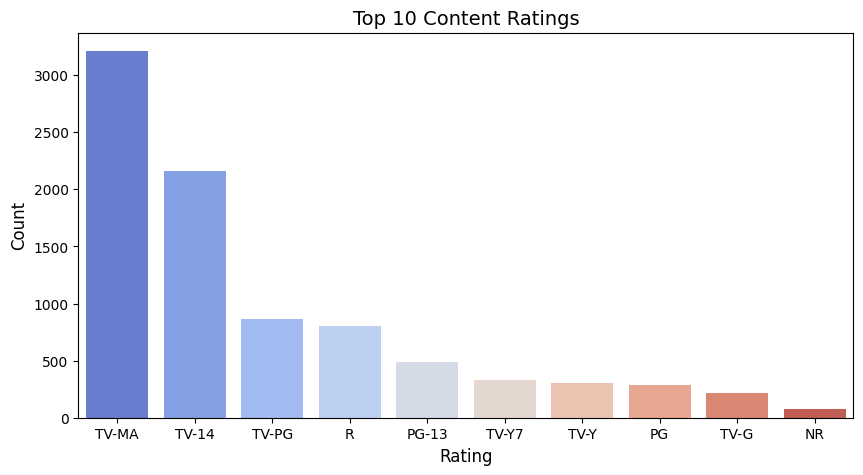

In [40]:
# Top 10 Ratings
top_ratings = df['rating'].value_counts().head(10)

plt.figure(figsize=(10,5))

sns.barplot(x=top_ratings.index,
            y=top_ratings.values,
            hue=top_ratings.index,
            palette='coolwarm',
            legend=False)

plt.title("Top 10 Content Ratings", fontsize=14)
plt.xlabel("Rating", fontsize=12)
plt.ylabel("Count", fontsize=12)

plt.show()

TV-MA has the highest number of titles on Netflix.
Netflix mainly focuses on mature audience entertainment.

## Content Analysis ------ Part 2

In [41]:
# Separate Movies and TV Shows
movies = df[df['type'] == 'Movie'].copy()
tvshows = df[df['type'] == 'TV Show'].copy()
print("Total Movies :", movies.shape[0])
print("Total TV Shows :", tvshows.shape[0])

Total Movies : 6128
Total TV Shows : 2676


In [42]:
movies['duration'] = movies['duration'].str.replace(' min', '').astype(int)

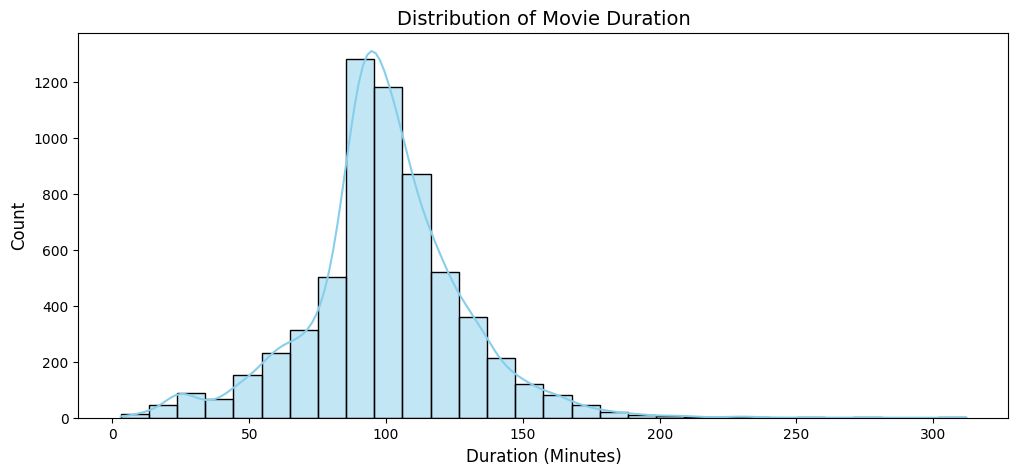

In [43]:
# Movie Duration Distribution
plt.figure(figsize=(12,5))

sns.histplot(movies['duration'],
             bins=30,
             kde=True,
             color='skyblue')

plt.title("Distribution of Movie Duration", fontsize=14)
plt.xlabel("Duration (Minutes)", fontsize=12)
plt.ylabel("Count", fontsize=12)

plt.show()

Most Netflix movies are between 80–120 minutes long.
Medium-length movies are more common on the platform.

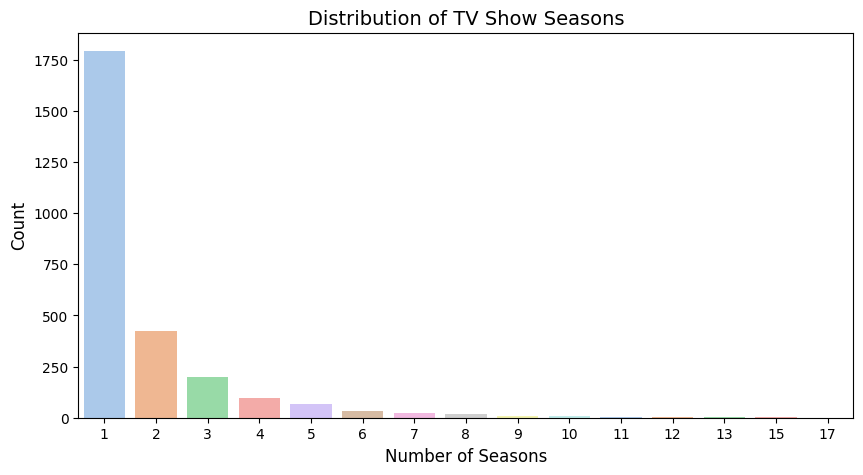

In [44]:
# TV Show Seasons Distribution
tvshows = df[df['type'] == 'TV Show'].copy()

tvshows['season_count'] = tvshows['duration'].str.replace(' Seasons', '')
tvshows['season_count'] = tvshows['season_count'].str.replace(' Season', '').astype(int)

plt.figure(figsize=(10,5))

sns.countplot(x='season_count',
              data=tvshows,
              hue='season_count',
              palette='pastel',
              legend=False)

plt.title("Distribution of TV Show Seasons", fontsize=14)
plt.xlabel("Number of Seasons", fontsize=12)
plt.ylabel("Count", fontsize=12)

plt.show()

Most TV Shows on Netflix have only 1 season.
Long-running TV Shows are fewer in number.

#### Overall Observation of Content Analysis:
* In Content Analysis, we analyzed Netflix content ratings and content duration to understand audience targeting and viewing patterns. The analysis showed that ratings like TV-MA and TV-14 are the most common, which means Netflix mainly focuses on teenage and mature audiences.
* We also found that most Netflix movies are medium-length (around 80–120 minutes), while most TV Shows contain only 1 season. This indicates that Netflix prefers easily consumable entertainment content rather than very long-duration series.

## Top Lists and Recommendations

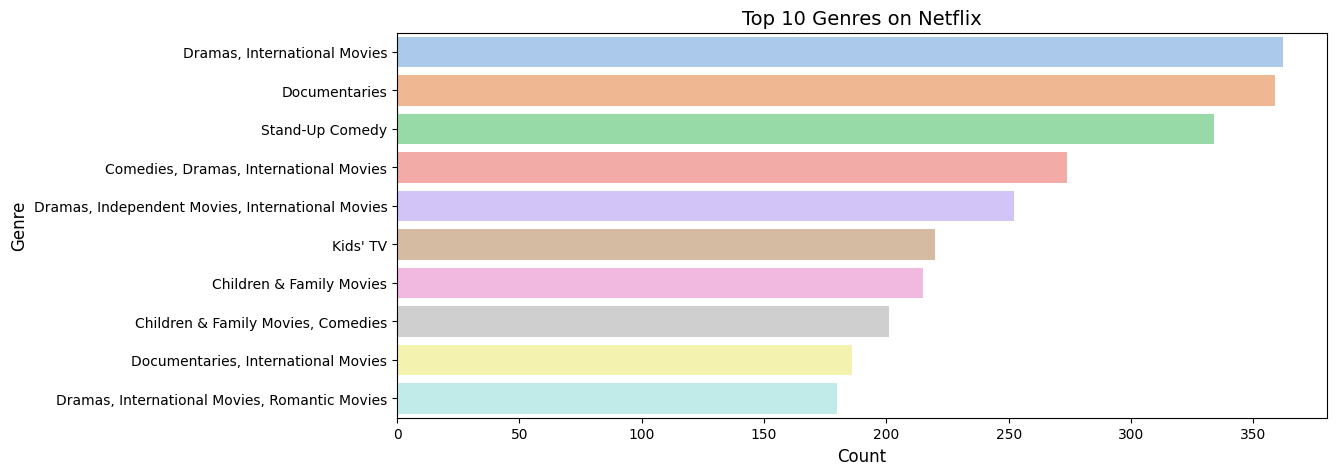

In [45]:
# Top 10 Genres on Netflix
top_genres = df['listed_in'].value_counts().head(10)

plt.figure(figsize=(12,5))

sns.barplot(x=top_genres.values,
            y=top_genres.index,
            hue=top_genres.index,
            palette='pastel',
            legend=False)

plt.title("Top 10 Genres on Netflix", fontsize=14)
plt.xlabel("Count", fontsize=12)
plt.ylabel("Genre", fontsize=12)
plt.show()

Drama and International Movies are among the most popular genres on Netflix.
Netflix provides diverse entertainment categories for viewers.

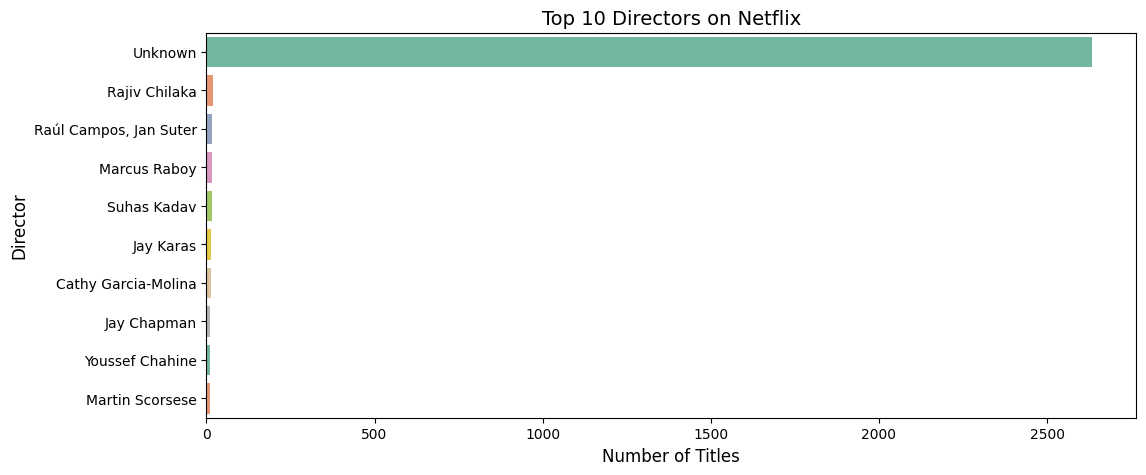

In [46]:
# Top 10 Directors
top_directors = df['director'].value_counts().head(10)

plt.figure(figsize=(12,5))

sns.barplot(x=top_directors.values,
            y=top_directors.index,
            hue=top_directors.index,
            palette='Set2',
            legend=False)

plt.title("Top 10 Directors on Netflix", fontsize=14)
plt.xlabel("Number of Titles", fontsize=12)
plt.ylabel("Director", fontsize=12)

plt.show()

Some directors contribute significantly more content than others.
Popular directors have multiple titles available on Netflix.

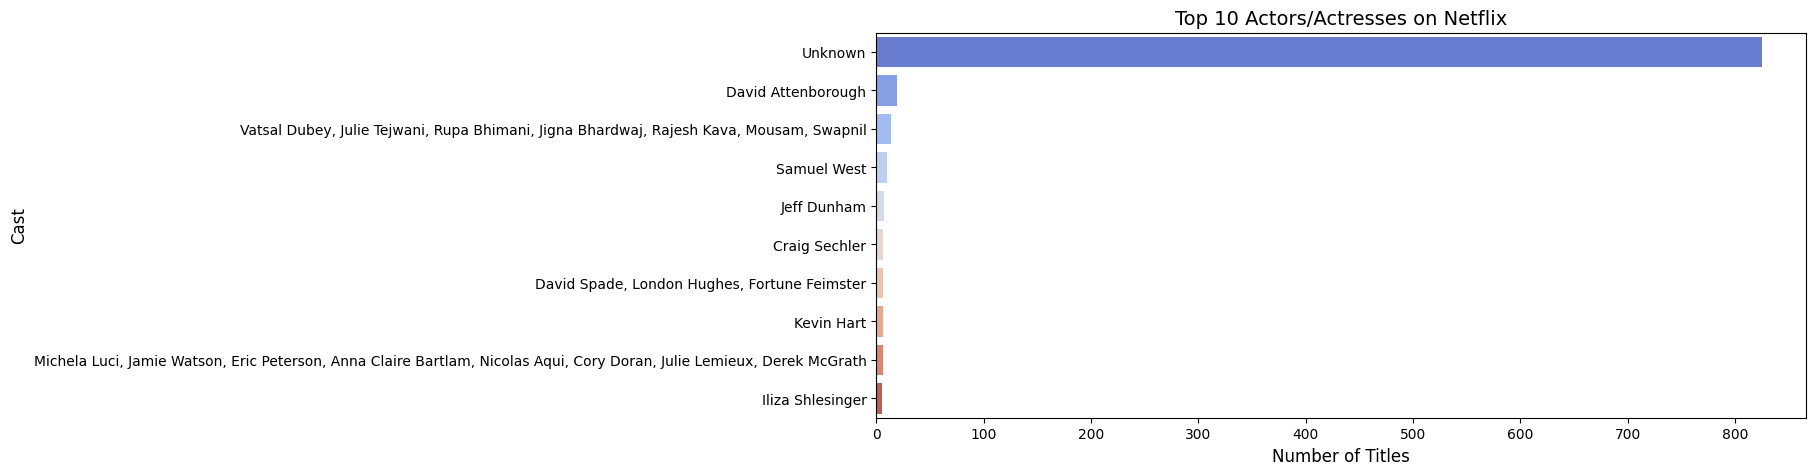

In [47]:
#Top 10 Actors/Actresses
top_cast = df['cast'].value_counts().head(10)

plt.figure(figsize=(12,5))

sns.barplot(x=top_cast.values,
            y=top_cast.index,
            hue=top_cast.index,
            palette='coolwarm',
            legend=False)

plt.title("Top 10 Actors/Actresses on Netflix", fontsize=14)
plt.xlabel("Number of Titles", fontsize=12)
plt.ylabel("Cast", fontsize=12)

plt.show()

Certain actors and actresses appear more frequently in Netflix content.
Popular cast members contribute to audience engagement.

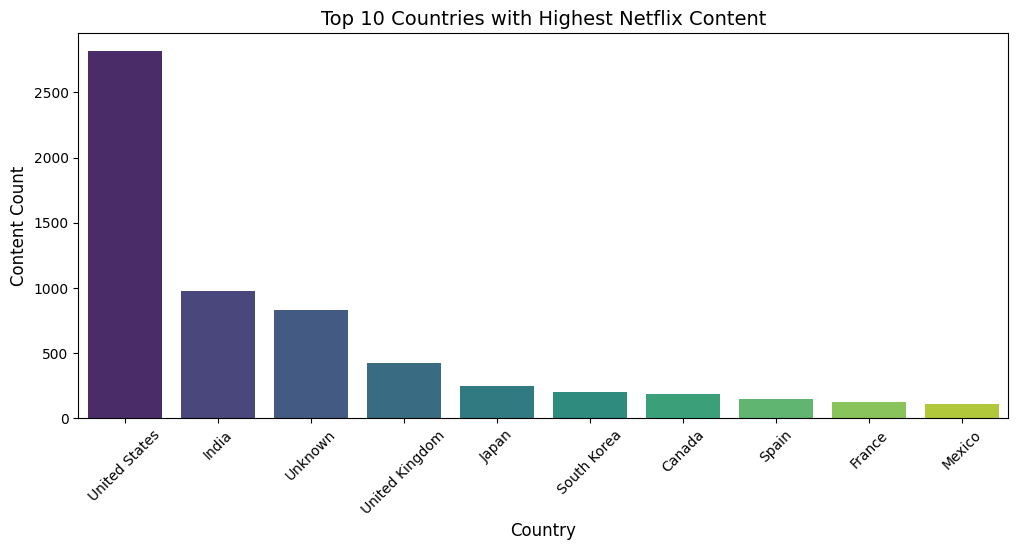

In [48]:
# Top 10 Countries with Highest Content
top_country = df['country'].value_counts().head(10)

plt.figure(figsize=(12,5))

sns.barplot(x=top_country.index,
            y=top_country.values,
            hue=top_country.index,
            palette='viridis',
            legend=False)

plt.title("Top 10 Countries with Highest Netflix Content", fontsize=14)
plt.xlabel("Country", fontsize=12)
plt.ylabel("Content Count", fontsize=12)

plt.xticks(rotation=45)

plt.show()

he United States has the highest Netflix content production.
India and the United Kingdom are also major contributors.

#### Overall Observation:
* Netflix contains a diverse range of genres, directors, actors, and countries.
* The platform mainly focuses on globally popular entertainment content with strong contributions from major film industries.

## Genre Trends

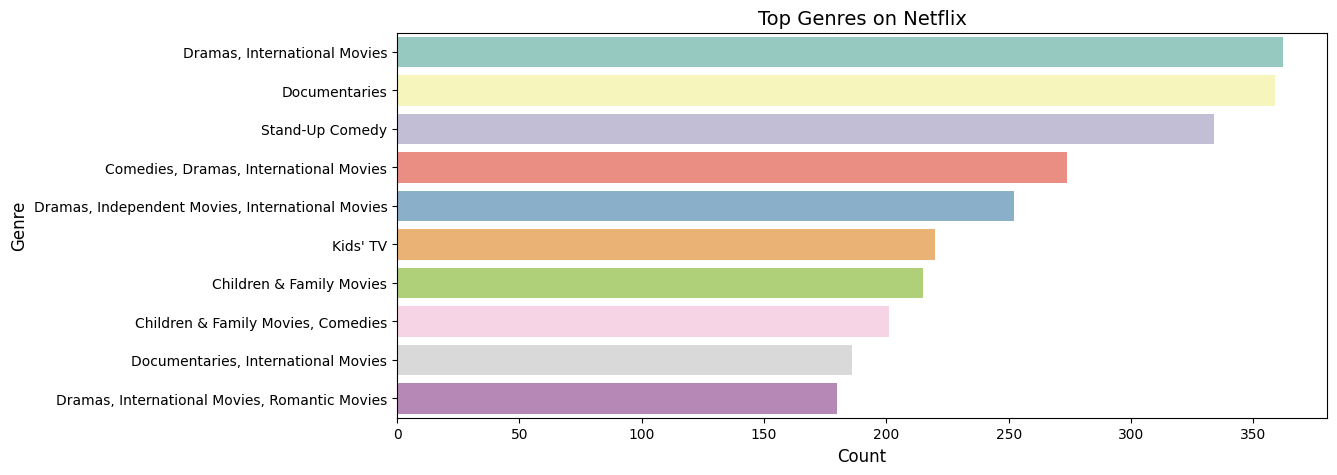

In [49]:
# Top Genres on Netflix
top_genres = df['listed_in'].value_counts().head(10)

plt.figure(figsize=(12,5))

sns.barplot(x=top_genres.values,
            y=top_genres.index,
            hue=top_genres.index,
            palette='Set3',
            legend=False)

plt.title("Top Genres on Netflix", fontsize=14)
plt.xlabel("Count", fontsize=12)
plt.ylabel("Genre", fontsize=12)

plt.show()

Drama and International Movies are among the most popular genres.
Netflix provides content for a wide variety of audience interests.

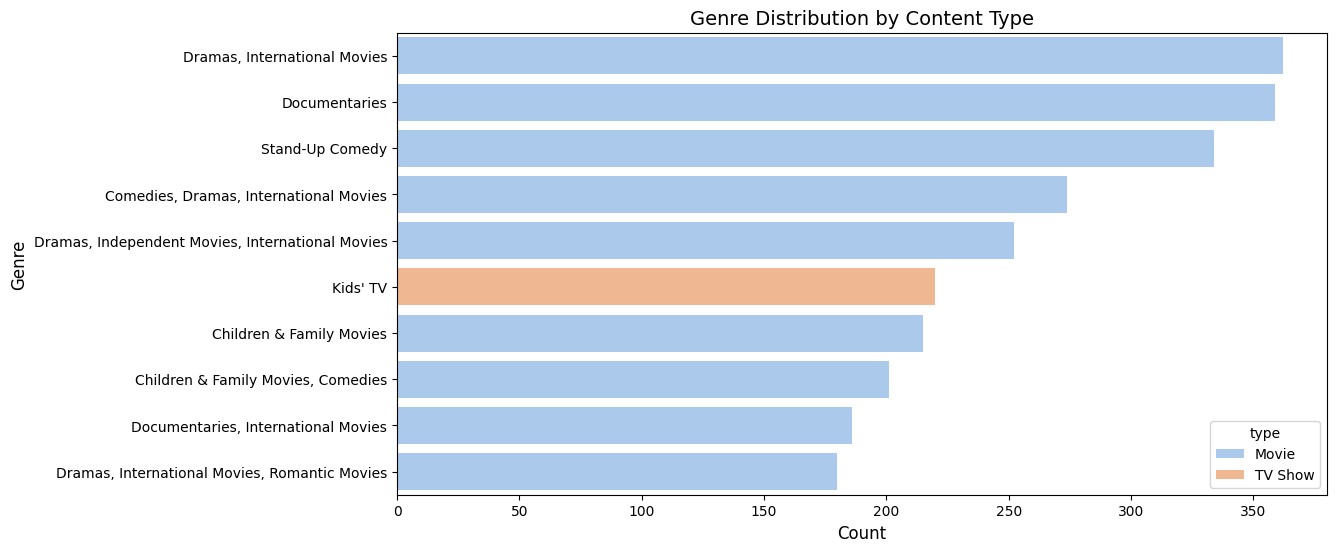

In [50]:
# Genre Distribution by Content Type
plt.figure(figsize=(12,6))

sns.countplot(y='listed_in',
              data=df,
              order=df['listed_in'].value_counts().iloc[:10].index,
              hue='type',
              palette='pastel')

plt.title("Genre Distribution by Content Type", fontsize=14)
plt.xlabel("Count", fontsize=12)
plt.ylabel("Genre", fontsize=12)

plt.show()

Movies dominate most genres on Netflix.
TV Shows are fewer compared to Movies in major categories.

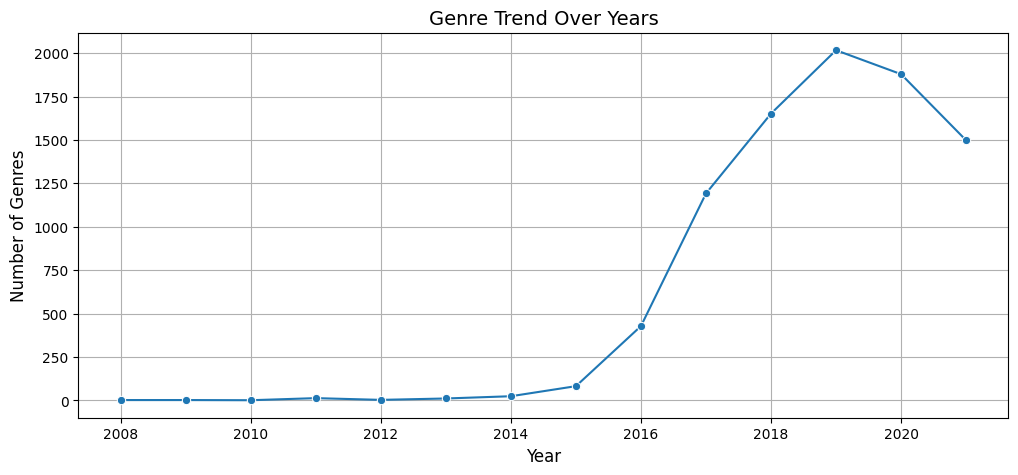

In [51]:
# Genre Trend Over Years
genre_year = df.groupby('year_added')['listed_in'].count()

plt.figure(figsize=(12,5))

sns.lineplot(x=genre_year.index,
             y=genre_year.values,
             marker='o')

plt.title("Genre Trend Over Years", fontsize=14)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Number of Genres", fontsize=12)

plt.grid(True)

plt.show()

Genre-based content increased rapidly after 2015.
Netflix expanded its variety of entertainment categories over time.

#### Overall Observation:
* Netflix offers a diverse range of genres, with Drama and International content being the most common.
* Genre diversity has increased significantly over the years, showing Netflix’s continuous expansion in entertainment categories.

## Geographical Analysis

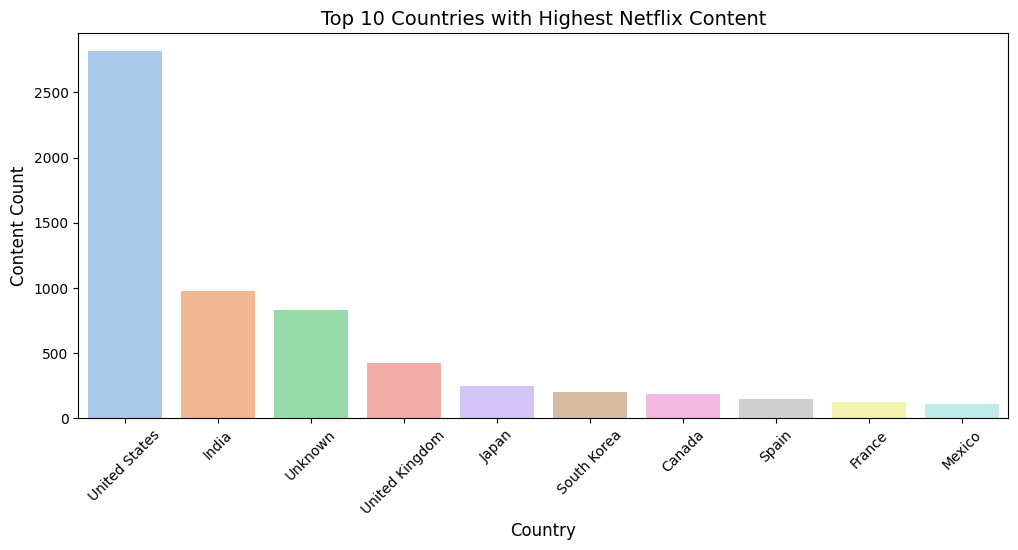

In [52]:
# Top 10 Countries with Highest Content
top_countries = df['country'].value_counts().head(10)

plt.figure(figsize=(12,5))

sns.barplot(x=top_countries.index,
            y=top_countries.values,
            hue=top_countries.index,
            palette='pastel',
            legend=False)

plt.title("Top 10 Countries with Highest Netflix Content", fontsize=14)
plt.xlabel("Country", fontsize=12)
plt.ylabel("Content Count", fontsize=12)

plt.xticks(rotation=45)

plt.show()

The United States contributes the highest amount of Netflix content.
India and the United Kingdom are also major content contributors.

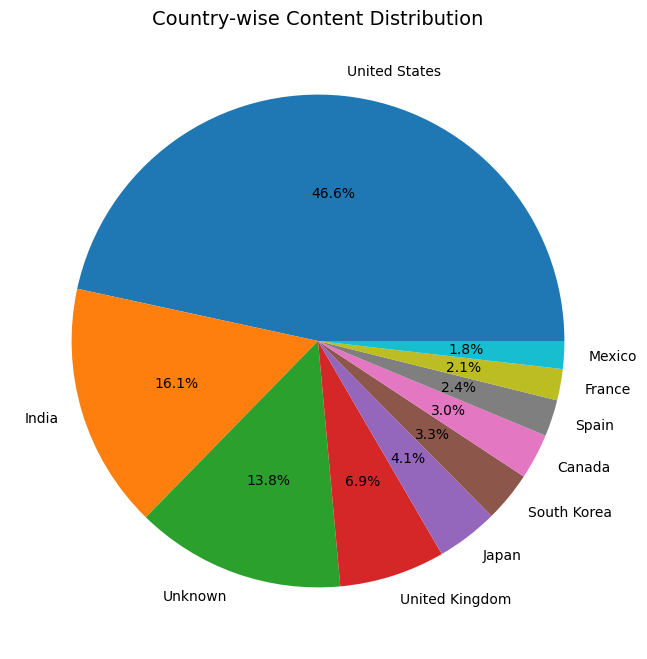

In [53]:
# Country-wise Content Distribution
country_data = df['country'].value_counts().head(10)

plt.figure(figsize=(8,8))

plt.pie(country_data.values,
        labels=country_data.index,
        autopct='%1.1f%%')

plt.title("Country-wise Content Distribution", fontsize=14)

plt.show()

A large percentage of Netflix content comes from a few major countries.
The United States dominates the overall distribution.

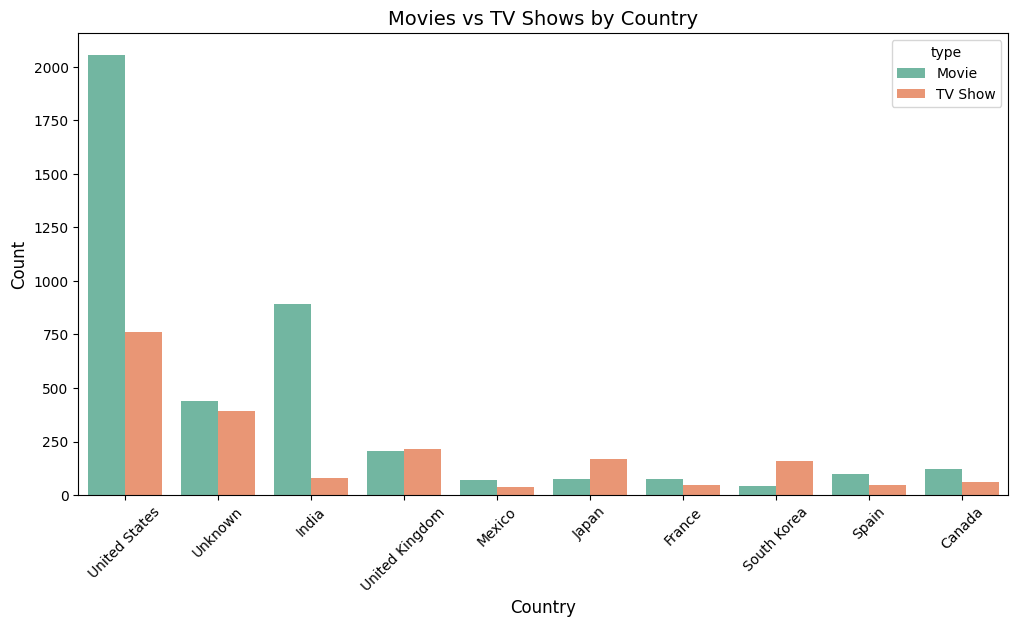

In [54]:
# Movies vs TV Shows by Country
top10 = df['country'].value_counts().head(10).index

filtered_df = df[df['country'].isin(top10)]

plt.figure(figsize=(12,6))

sns.countplot(x='country',
              data=filtered_df,
              hue='type',
              palette='Set2')

plt.title("Movies vs TV Shows by Country", fontsize=14)
plt.xlabel("Country", fontsize=12)
plt.ylabel("Count", fontsize=12)

plt.xticks(rotation=45)

plt.show()

Movies are more common than TV Shows in most countries.
Some countries contribute relatively more TV Shows compared to others.

#### Overall Observation:
* Netflix content is globally distributed, but most content comes from countries like the United States and India.
* Movies dominate across most regions, showing Netflix’s stronger focus on movie-based entertainment worldwide.

## Correlation Analysis

In [55]:
# Create Numeric Dataset for Correlation
numeric_df = movies[['release_year', 'duration', 'year_added']]

In [56]:
# Correlation Matrix
corr_matrix = numeric_df.corr()

corr_matrix

,release_year,duration,year_added
release_year,1.000000,-0.206285,0.039351
duration,-0.206285,1.000000,0.124436
year_added,0.039351,0.124436,1.000000


Displays correlation values between variables.

Correlation values range from -1 to +1.

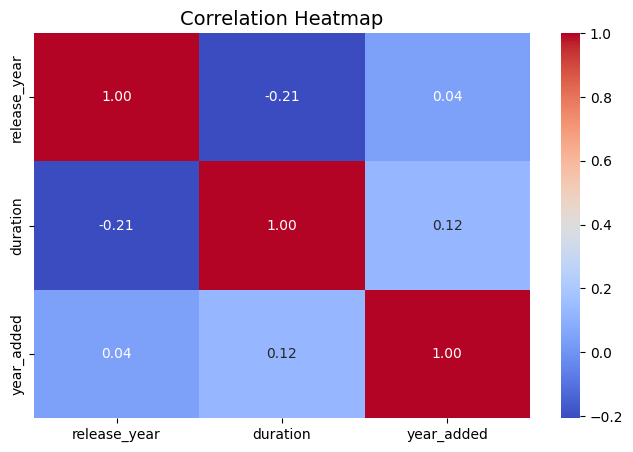

In [57]:
# Heatmap Visualization
plt.figure(figsize=(8,5))

sns.heatmap(corr_matrix,
            annot=True,
            cmap='coolwarm',
            fmt='.2f')

plt.title("Correlation Heatmap", fontsize=14)

plt.show()

Heatmap visually represents relationships between variables.

Darker colors indicate stronger correlation.



#### Overall Observation:

* Correlation analysis showed that Release Year and Year Added have a positive relationship, which means newer content is usually added to Netflix more quickly. On the other hand, movie duration has a weak correlation with other variables, indicating that content length does not strongly depend on release year or upload year.

* Overall, most relationships between variables are weak to moderate, but the strongest connection is observed between release year and the year content was added to Netflix.


## Audience Engagement ----- Part 1

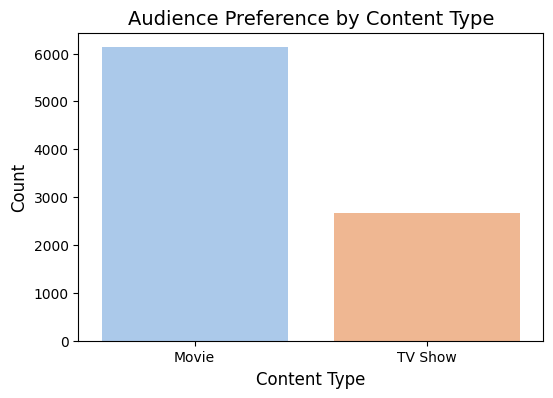

In [58]:
# Audience Preference by Content Type
plt.figure(figsize=(6,4))

sns.countplot(x='type',
              data=df,
              hue='type',
              palette='pastel',
              legend=False)

plt.title("Audience Preference by Content Type", fontsize=14)
plt.xlabel("Content Type", fontsize=12)
plt.ylabel("Count", fontsize=12)

plt.show()

Movies are more common than TV Shows on Netflix.
This suggests that movie content receives strong audience attention on the platform.

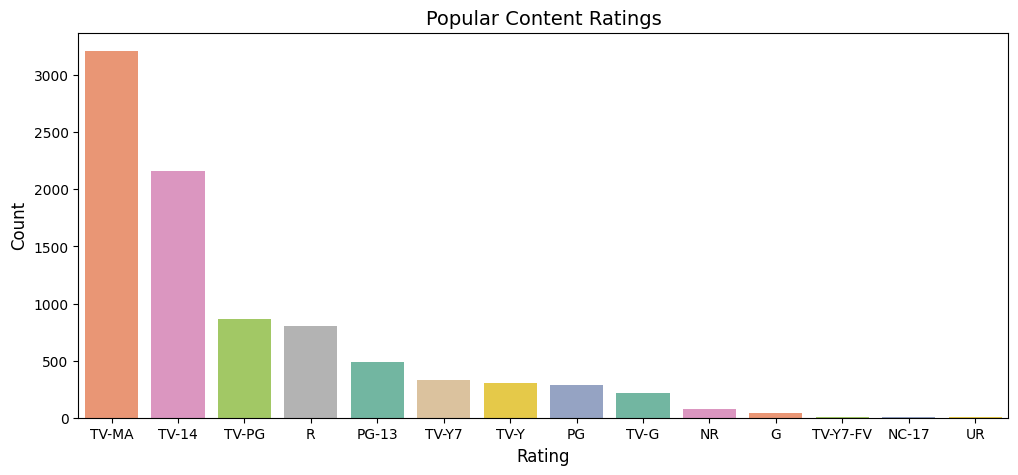

In [59]:
# Popular Ratings Among Audience
plt.figure(figsize=(12,5))

sns.countplot(x='rating',
              data=df,
              order=df['rating'].value_counts().index,
              hue='rating',
              palette='Set2',
              legend=False)

plt.title("Popular Content Ratings", fontsize=14)
plt.ylabel("Count", fontsize=12)
plt.xlabel("Rating", fontsize=12)

plt.show()

Ratings like TV-MA and TV-14 dominate Netflix.
The platform mainly targets teenage and mature audiences.

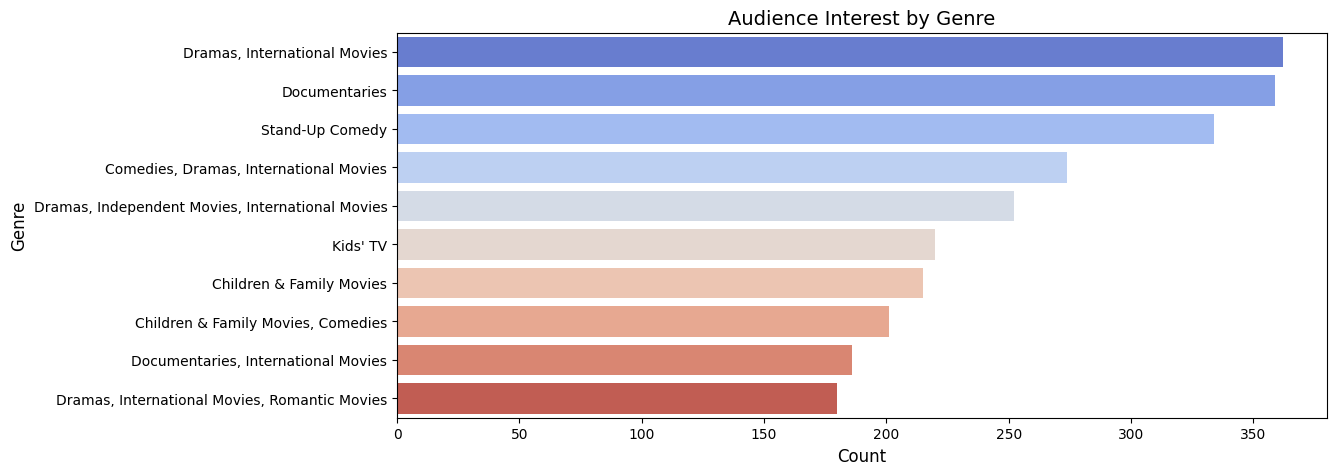

In [60]:
# Audience Interest by Genre
top_genres = df['listed_in'].value_counts().head(10)

plt.figure(figsize=(12,5))

sns.barplot(x=top_genres.values,
            y=top_genres.index,
            hue=top_genres.index,
            palette='coolwarm',
            legend=False)

plt.title("Audience Interest by Genre", fontsize=14)
plt.xlabel("Count", fontsize=12)
plt.ylabel("Genre", fontsize=12)

plt.show()

Drama and International Movies are among the most preferred genres.
Viewers show strong interest in story-based and globally diverse content.

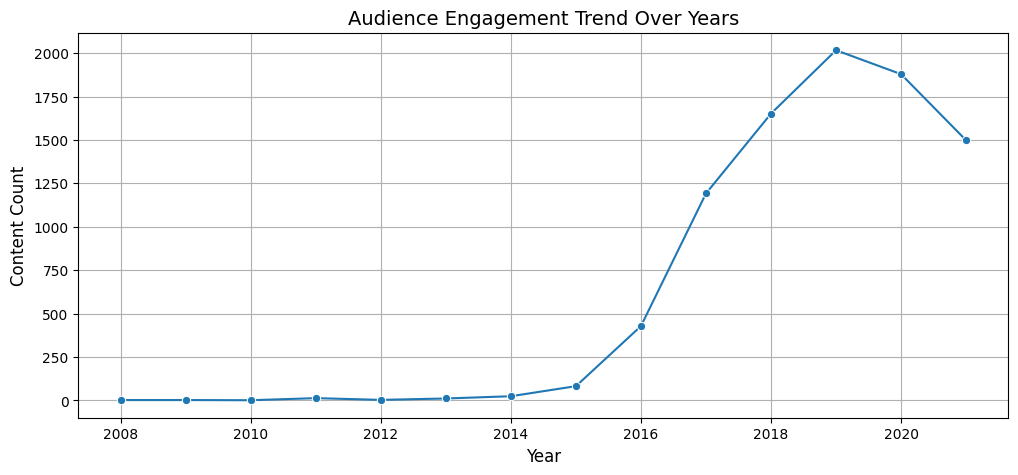

In [61]:
# Audience Engagement Trend Over Years
year_data = df['year_added'].value_counts().sort_index()

plt.figure(figsize=(12,5))

sns.lineplot(x=year_data.index,
             y=year_data.values,
             marker='o')

plt.title("Audience Engagement Trend Over Years", fontsize=14)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Content Count", fontsize=12)

plt.grid(True)

plt.show()

Netflix content increased rapidly after 2015.
Increased content availability may indicate growing audience engagement and platform expansion.

#### Overall Observation:

* The analysis shows that Movies are much more common on Netflix than TV Shows, indicating that the platform mainly focuses on movie-based entertainment. Ratings like TV-MA and TV-14 have the highest counts, which means Netflix mainly targets teenage and mature audiences.

* Genre analysis revealed that Drama, International Movies, Documentaries, and Stand-Up Comedy are among the most popular categories. The yearly trend graph also shows rapid growth in Netflix content after 2015, with peak expansion around 2019–2020, indicating increasing audience engagement and platform growth over time.


## Audience Engagement ----- Part 2

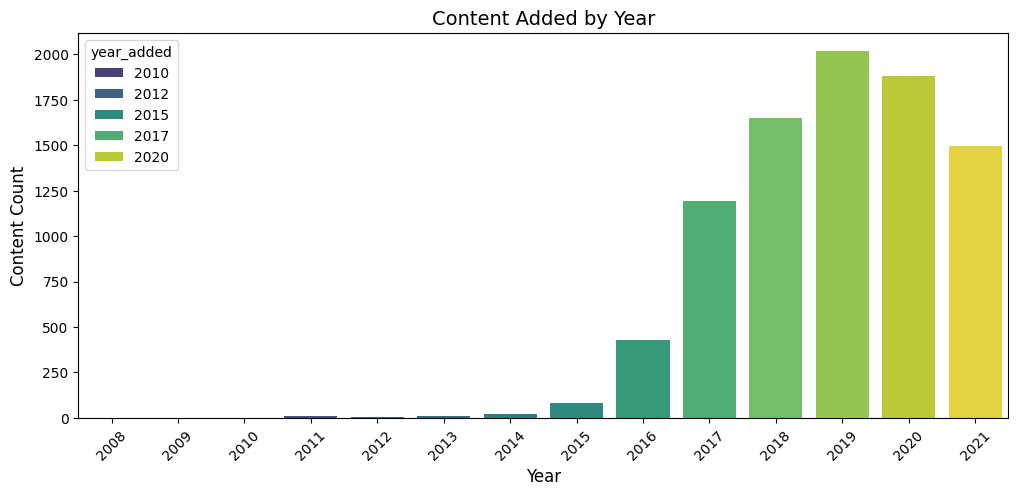

In [62]:
# Content Added by Year
year_data = df['year_added'].value_counts().sort_index()
plt.figure(figsize=(12,5))
sns.barplot(x=year_data.index,
            y=year_data.values,
            hue=year_data.index,
            palette='viridis')

plt.title("Content Added by Year", fontsize=14)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Content Count", fontsize=12)

plt.xticks(rotation=45)

plt.show()

Netflix content increased rapidly after 2016.
The platform experienced major expansion during recent years.

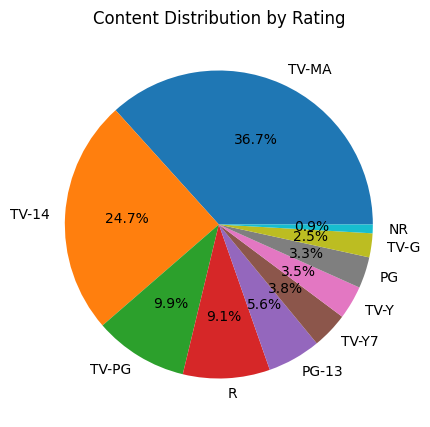

In [63]:
# Content Distribution by Rating Type
plt.figure(figsize=(10,5))

df['rating'].value_counts().head(10).plot(kind='pie',
                                          autopct='%1.1f%%')

plt.title("Content Distribution by Rating")

plt.ylabel('')

plt.show()

Mature audience ratings dominate Netflix content.
Teen and family-friendly categories are also available but in lower numbers.

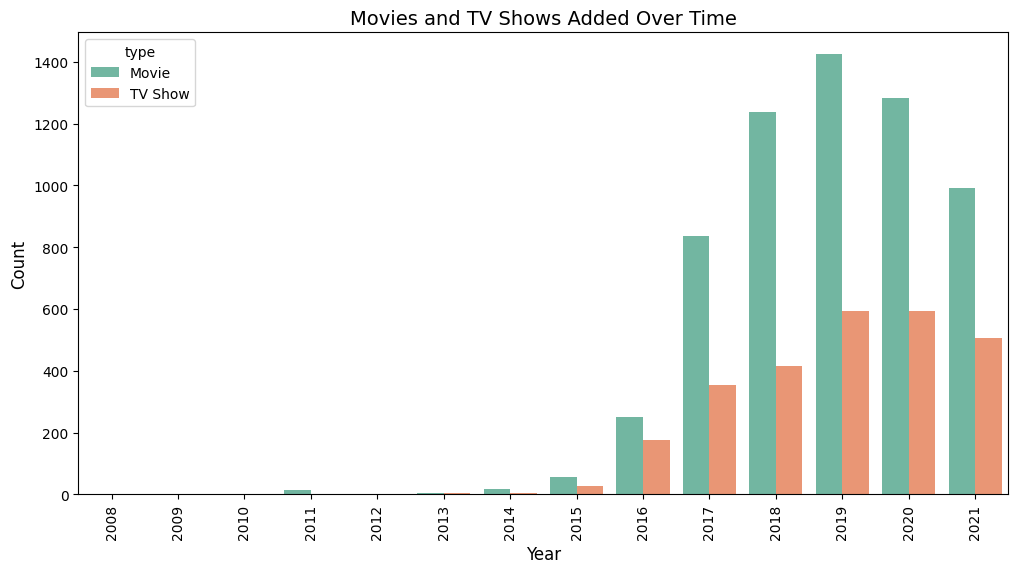

In [64]:
# Movies and TV Shows Added Over Time
plt.figure(figsize=(12,6))

sns.countplot(x='year_added',
              data=df,
              hue='type',
              palette='Set2')

plt.title("Movies and TV Shows Added Over Time", fontsize=14)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Count", fontsize=12)

plt.xticks(rotation=90)

plt.show()

Movies consistently remain higher than TV Shows.
Both content types increased significantly after 2016.

#### Overall Observation:
* Netflix audience engagement increased significantly after 2015 due to rapid content growth and platform expansion.
* The platform mainly focuses on Movies and mature audience content while still maintaining variety across different viewer categories.

## Content Variety

In [65]:
# Number of Unique Genres
print("Unique Genres :", df['listed_in'].nunique())

Unique Genres : 514


In [66]:
# Number of Unique Ratings
print("Unique Ratings :", df['rating'].nunique())

Unique Ratings : 14


In [67]:
# Number of Unique Countries
print("Unique Countries :", df['country'].nunique())

Unique Countries : 749


In [68]:
# Content Variety by Type
df['type'].value_counts()

type
Movie      6128
TV Show    2676
Name: count, dtype: int64

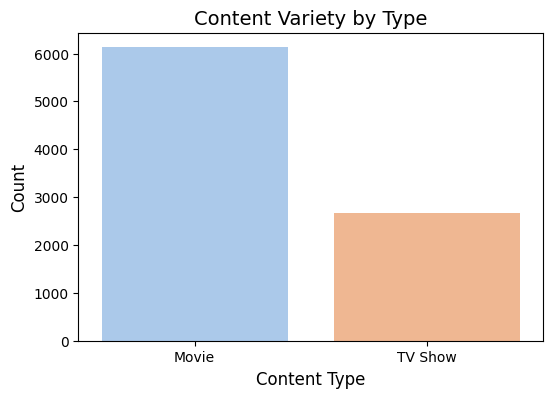

In [69]:
# Visualization of Content Variety
plt.figure(figsize=(6,4))

sns.countplot(x='type',
              data=df,
              hue='type',
              palette='pastel',
              legend=False)

plt.title("Content Variety by Type", fontsize=14)
plt.xlabel("Content Type", fontsize=12)
plt.ylabel("Count", fontsize=12)

plt.show()

Movies are more common than TV Shows.
Netflix maintains a wide variety of entertainment content.

#### Overall Observation:
* Netflix provides highly diverse content across genres, ratings, and countries.
* The platform contains a large variety of Movies and TV Shows, making it suitable for different audience preferences worldwide.

## Language Analysis

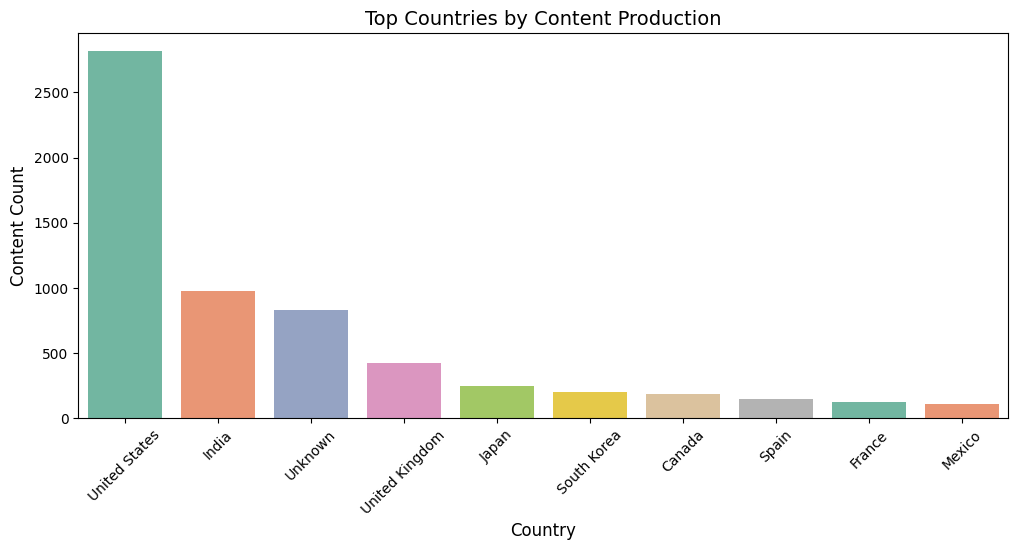

In [70]:
# Top Countries by Content Production
top_country = df['country'].value_counts().head(10)

plt.figure(figsize=(12,5))

sns.barplot(x=top_country.index,
            y=top_country.values,
            hue=top_country.index,
            palette='Set2',
            legend=False)

plt.title("Top Countries by Content Production", fontsize=14)
plt.xlabel("Country", fontsize=12)
plt.ylabel("Content Count", fontsize=12)

plt.xticks(rotation=45)

plt.show()

The United States contributes the highest amount of Netflix content.
India and the United Kingdom are also major contributors.

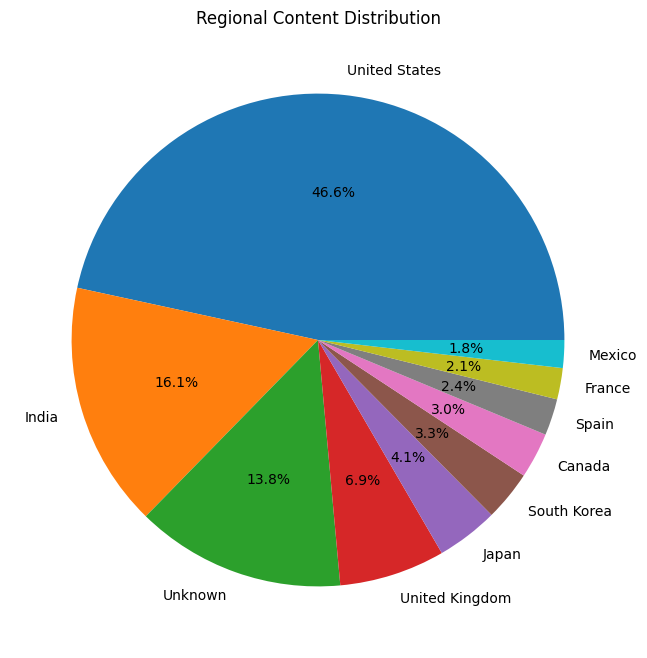

In [71]:
# Regional Content Distribution
plt.figure(figsize=(8,8))

df['country'].value_counts().head(10).plot(kind='pie',
                                           autopct='%1.1f%%')

plt.title("Regional Content Distribution")

plt.ylabel('')

plt.show()

Netflix content mainly comes from a few major regions.
The platform includes content from multiple countries worldwide.

In [72]:
# International Content Categories
international_content = df[df['listed_in'].str.contains('International', na=False)]

print("Total International Content :", international_content.shape[0])

Total International Content : 4103


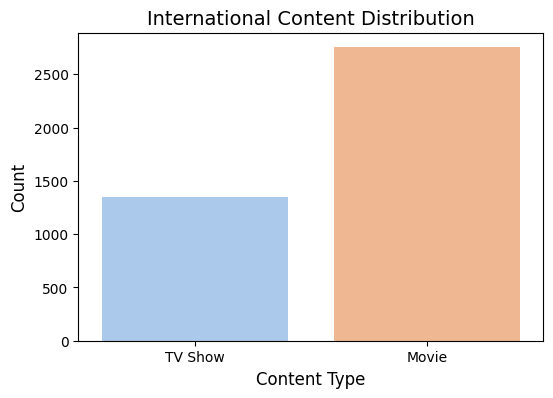

In [73]:
# Visualization of International Content
plt.figure(figsize=(6,4))

sns.countplot(x='type',
              data=international_content,
              hue='type',
              palette='pastel',
              legend=False)

plt.title("International Content Distribution", fontsize=14)
plt.xlabel("Content Type", fontsize=12)
plt.ylabel("Count", fontsize=12)

plt.show()

International Movies are more common than International TV Shows.
Netflix strongly focuses on globally diverse entertainment content.

#### Overall Observation:
* Netflix provides content from many countries and regions, showing strong global reach and audience diversity.

* International Movies and region-based entertainment play an important role in Netflix’s content library.

## Content Evolution Over Time

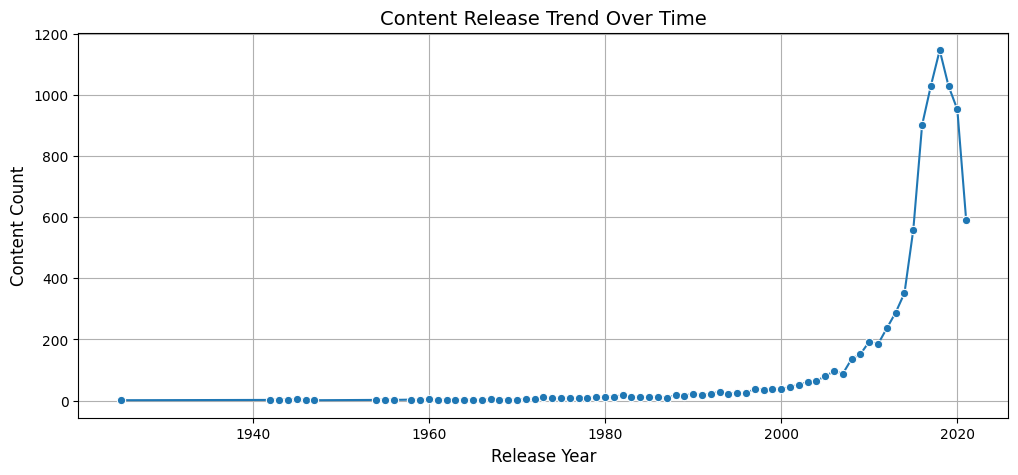

In [74]:
# Content Release Trend Over Time
release_trend = df['release_year'].value_counts().sort_index()

plt.figure(figsize=(12,5))

sns.lineplot(x=release_trend.index,
             y=release_trend.values,
             marker='o')

plt.title("Content Release Trend Over Time", fontsize=14)
plt.xlabel("Release Year", fontsize=12)
plt.ylabel("Content Count", fontsize=12)

plt.grid(True)

plt.show()

Netflix content releases increased significantly after 2000.
The platform mainly focuses on modern and recent content

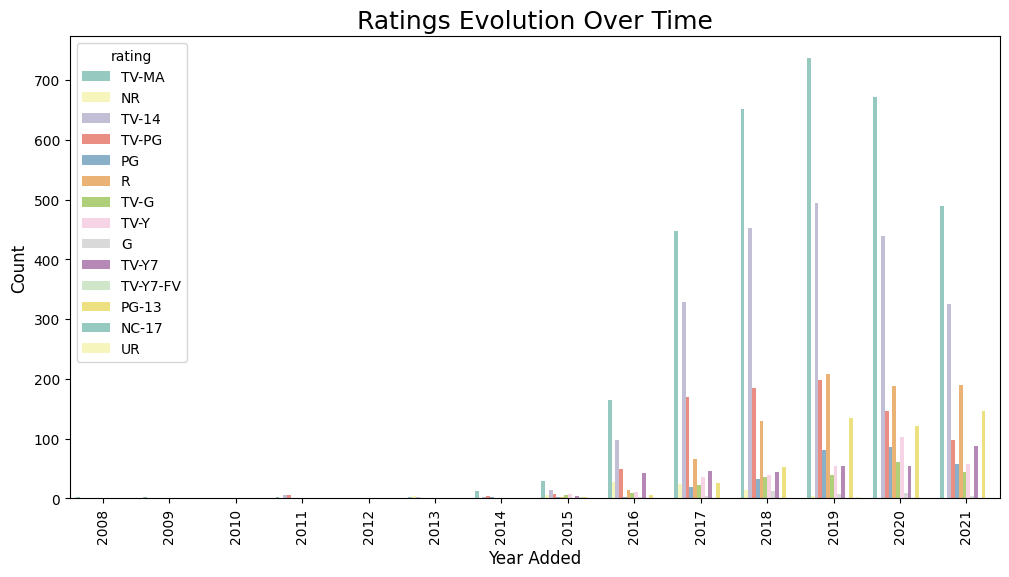

In [75]:
# Ratings Evolution Over Time
plt.figure(figsize=(12,6))

sns.countplot(x='year_added',
              data=df,
              hue='rating',
              palette='Set3')

plt.title("Ratings Evolution Over Time", fontsize=18)
plt.xlabel("Year Added", fontsize=12)
plt.ylabel("Count", fontsize=12)

plt.xticks(rotation=90)

plt.show()

Mature audience ratings increased rapidly in recent years.
Netflix expanded content categories for different viewer groups over time.

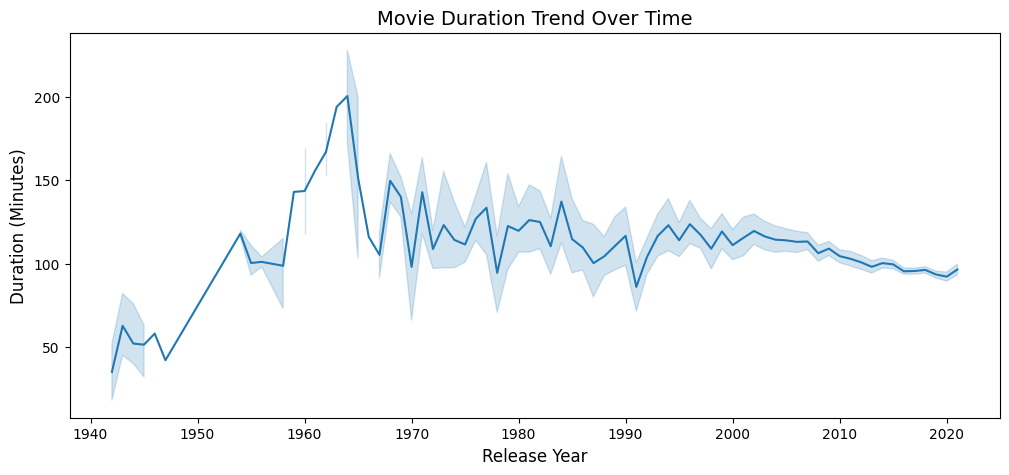

In [76]:
# Movie Duration Trend
movies = df[df['type'] == 'Movie'].copy()

movies['duration'] = movies['duration'].str.replace(' min','').astype(int)

plt.figure(figsize=(12,5))

sns.lineplot(x=movies['release_year'],
             y=movies['duration'])

plt.title("Movie Duration Trend Over Time", fontsize=14)
plt.xlabel("Release Year", fontsize=12)
plt.ylabel("Duration (Minutes)", fontsize=12)

plt.show()

Most movies maintain medium-length durations over the years.
Extreme duration changes are less common in Netflix movie content

#### Overall Observation:

* Netflix content evolved significantly over time, especially after 2000 with rapid growth in modern content.
* The platform increasingly focused on mature audience categories while maintaining balanced movie durations and diverse entertainment content.


## User preferences

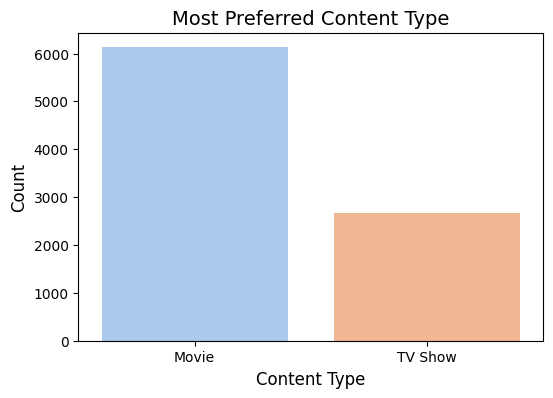

In [77]:
# Most Preferred Content Type
plt.figure(figsize=(6,4))

sns.countplot(x='type',
              data=df,
              hue='type',
              palette='pastel',
              legend=False)

plt.title("Most Preferred Content Type", fontsize=14)
plt.xlabel("Content Type", fontsize=12)
plt.ylabel("Count", fontsize=12)

plt.show()

Movies are more preferred and available compared to TV Shows.
Netflix audience shows strong interest in movie-based entertainment.

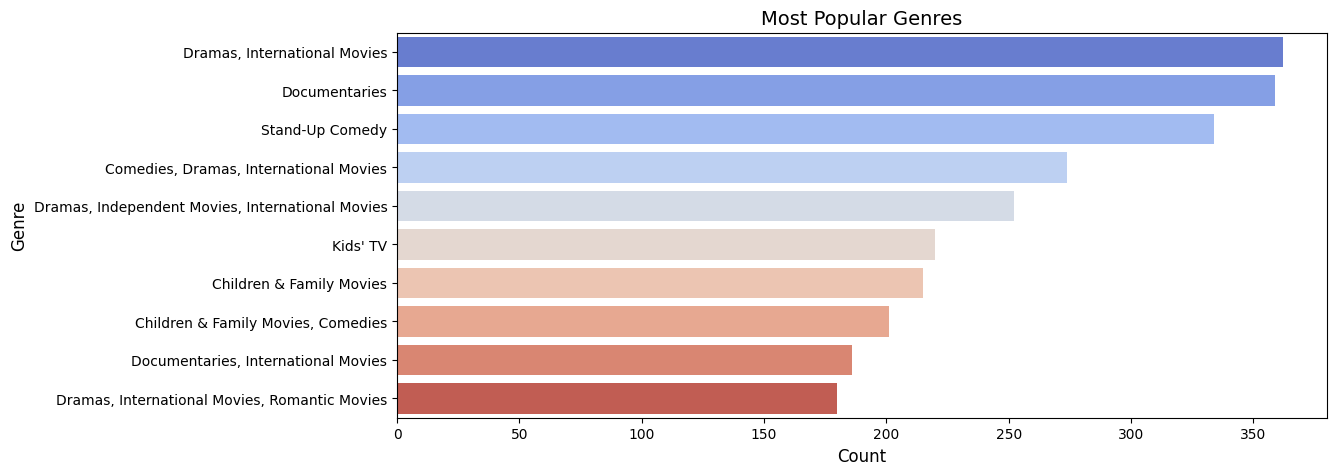

In [78]:
# Most Popular Genres
top_genres = df['listed_in'].value_counts().head(10)

plt.figure(figsize=(12,5))

sns.barplot(x=top_genres.values,
            y=top_genres.index,
            hue=top_genres.index,
            palette='coolwarm',
            legend=False)

plt.title("Most Popular Genres", fontsize=14)
plt.xlabel("Count", fontsize=12)
plt.ylabel("Genre", fontsize=12)

plt.show()

Drama, International Movies, and Comedy are highly preferred genres.
Users enjoy diverse and story-driven entertainment content.

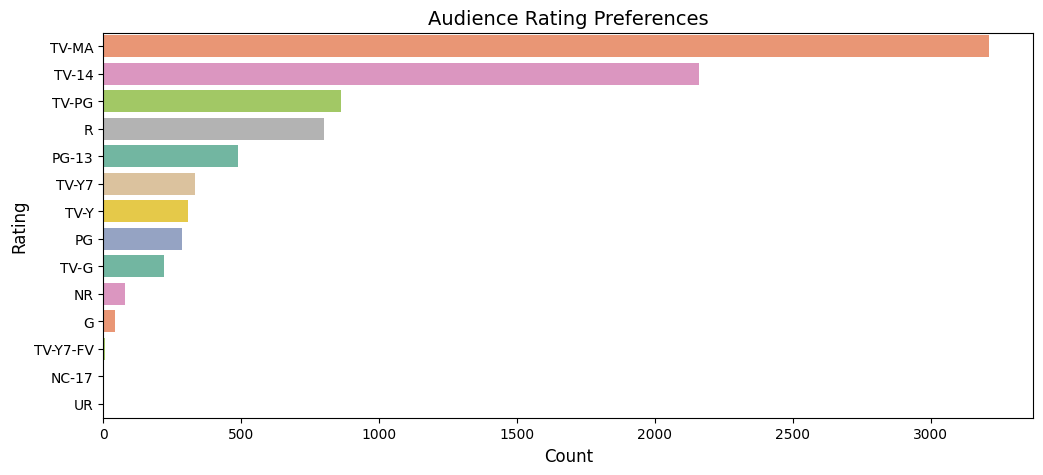

In [79]:
# Audience Rating Preferences
plt.figure(figsize=(12,5))

sns.countplot(y='rating',
              data=df,
              order=df['rating'].value_counts().index,
              hue='rating',
              palette='Set2',
              legend=False)

plt.title("Audience Rating Preferences", fontsize=14)
plt.xlabel("Count", fontsize=12)
plt.ylabel("Rating", fontsize=12)

plt.show()

TV-MA and TV-14 are the most common ratings.
Most Netflix users prefer teenage and mature audience content.

#### Overall Observation:
* Netflix users mainly prefer Movies, Drama, and mature-rated content.
* International and diverse genres also play an important role in audience engagement.

### Key Findings
* Movies are more dominant on Netflix than TV Shows.
* Drama, International Movies, and Comedy are among the most popular genres.
* TV-MA and TV-14 are the most common ratings, showing higher focus on teenage and mature audiences.
* Netflix content increased rapidly after 2015, especially during 2018–2020.
* The United States is the largest contributor of Netflix content, followed by India and the United Kingdom.
* Most movies have medium durations, while many TV Shows contain fewer seasons.

### Conclusions
* Netflix provides a highly diverse content library across genres, countries, and audience categories.
* The platform mainly focuses on Movies, mature-rated content, and internationally diverse entertainment.
* Continuous content growth over the years reflects increasing audience engagement and platform expansion.

### Recommendations
* Netflix should continue investing in popular genres such as Drama, Comedy, and International content.
* Expanding regional and multilingual content can help attract wider global audiences.
* Increasing family-friendly content may improve engagement across all age groups.
* Focusing on shorter and easily consumable content may improve audience retention and viewer satisfaction.